<a href="https://colab.research.google.com/github/Katab-sawan/Dissertation/blob/lstm-Models/TSLA_LSTM_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import datetime
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = yf.download('TSLA', start='2012-01-01', end=datetime.datetime.now())
df

/tmp/ipykernel_3440/768315680.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('TSLA', start='2012-01-01', end=datetime.datetime.now())
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2012-01-03,1.872000,1.966667,1.843333,1.929333,13921500
2012-01-04,1.847333,1.911333,1.833333,1.880667,9451500
2012-01-05,1.808000,1.862000,1.790000,1.850667,15082500
2012-01-06,1.794000,1.852667,1.760667,1.813333,14794500
2012-01-09,1.816667,1.832667,1.741333,1.800000,13455000
...,...,...,...,...,...
2026-03-19,380.299988,387.269989,378.730011,387.269989,67078300
2026-03-20,367.959991,379.890015,364.459991,379.850006,78628600


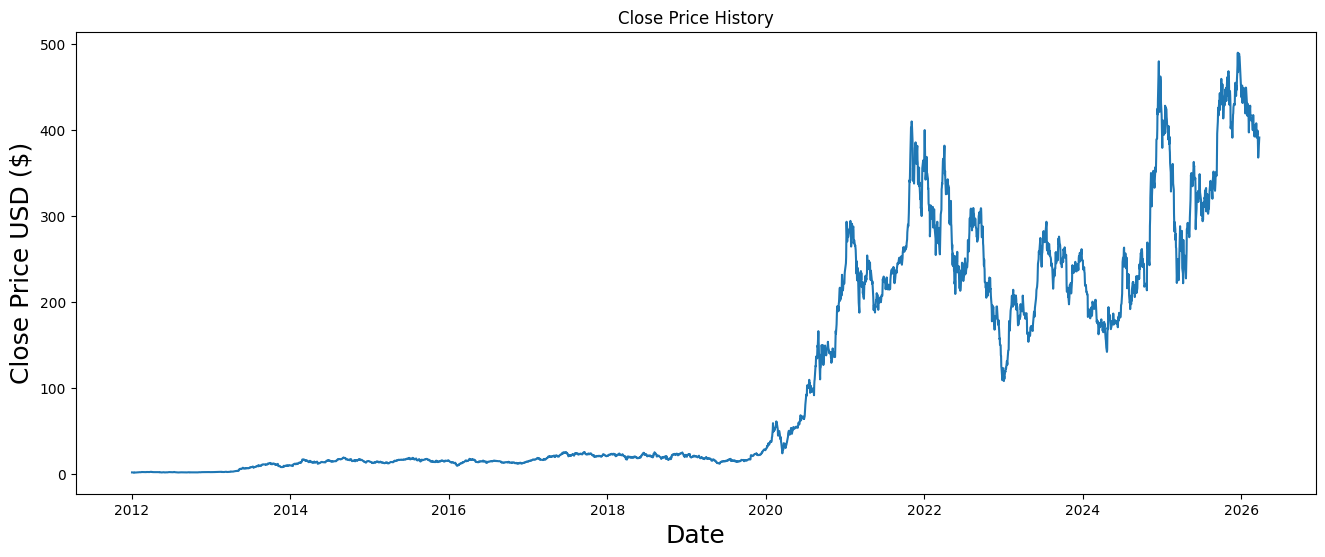

In [ ]:
plt.figure(figsize=(16,6))
plt.title('Close Price History')
plt.plot(df['Close'])
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)
plt.show()

In [ ]:

data = df.filter(['Close'])
dataset = data.values
training_data_len = int(np.ceil( len(dataset) * .95 ))

training_data_len

3399

In [ ]:
from sklearn.preprocessing import MinMaxScaler
dataset = df[['Close']]
scaler = MinMaxScaler(feature_range=(0, 1))

scaled_data = scaler.fit_transform(dataset)
scaled_data

array([[7.22144502e-04],
       [6.71634651e-04],
       [5.91093796e-04],
       ...,
       [7.76742877e-01],
       [7.81206776e-01],
       [7.98550517e-01]])

In [ ]:


train_data = scaled_data[0:int(training_data_len), :]

x_train = []
y_train = []

for i in range(60, len(train_data)):
    x_train.append(train_data[i-60:i, 0])
    y_train.append(train_data[i, 0])
    if i<= 61:
        print(x_train)
        print(y_train)
        print()

x_train, y_train = np.array(x_train), np.array(y_train)

x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))


[array([0.00072214, 0.00067163, 0.00059109, 0.00056243, 0.00060884,
       0.00065935, 0.00074262, 0.00074535, 0.        , 0.00052011,
       0.00054877, 0.00054195, 0.00052011, 0.00054332, 0.00063205,
       0.00070713, 0.00083954, 0.00089278, 0.00092555, 0.00085729,
       0.00092691, 0.00101837, 0.00114123, 0.00122997, 0.00120266,
       0.00124771, 0.00133644, 0.00113441, 0.00118765, 0.00141699,
       0.00147569, 0.00155486, 0.00166271, 0.00159855, 0.00156032,
       0.00160264, 0.00149616, 0.00147842, 0.00150435, 0.00144975,
       0.00158626, 0.00153575, 0.00149889, 0.0014088 , 0.00141016,
       0.00140334, 0.00163131, 0.00180468, 0.0018156 , 0.00170639,
       0.0016668 , 0.00171049, 0.00166407, 0.00166134, 0.00168728,
       0.00158489, 0.00154121, 0.00199443, 0.00206814, 0.00205586])]
[np.float64(0.001984873193376103)]

[array([0.00072214, 0.00067163, 0.00059109, 0.00056243, 0.00060884,
       0.00065935, 0.00074262, 0.00074535, 0.        , 0.00052011,
       0.00054877, 0.0

In [ ]:

from keras.models import Sequential
from keras.layers import Dense, LSTM


model = Sequential()
model.add(LSTM(128, return_sequences=True, input_shape= (x_train.shape[1], 1)))
model.add(LSTM(64, return_sequences=False))
model.add(Dense(25))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')


model.fit(x_train, y_train, batch_size=1, epochs=1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


3339/3339 ━━━━━━━━━━━━━━━━━━━━ 120s 35ms/step - loss: 0.0012


In [ ]:

y_test = dataset.iloc[training_data_len:, :]

test_data = scaled_data[training_data_len - 60:, :]

x_test = []
for i in range(60, len(test_data)):
    x_test.append(test_data[i-60:i, 0])


x_test = np.array(x_test)


x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))


predictions = model.predict(x_test)
predictions = scaler.inverse_transform(predictions)

rmse = np.sqrt(np.mean(((predictions - y_test) ** 2)))
rmse


6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 121ms/step


np.float64(27.303672124532024)

/tmp/ipykernel_3440/2895496306.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['Predictions'] = predictions[:len(valid)]  # Ensure that predictions align with valid length


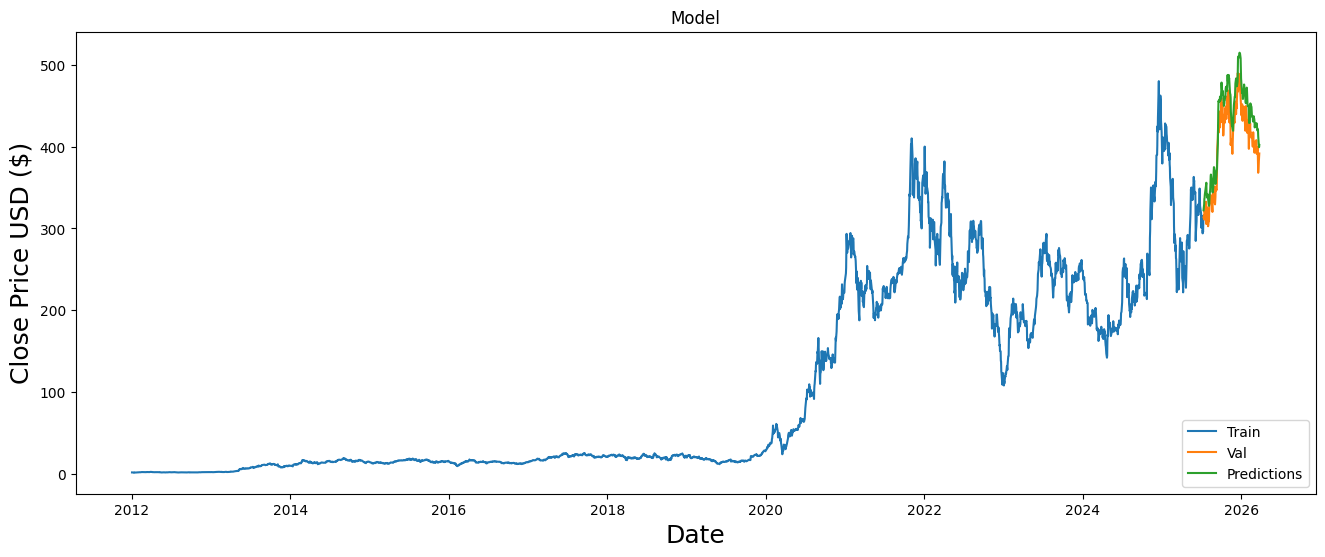

In [ ]:
data = df[['Close']]

dataset = data.values

training_data_len = int(np.ceil(len(dataset) * .95))

train = data.iloc[:training_data_len]
valid = data.iloc[training_data_len:]

valid['Predictions'] = predictions[:len(valid)]

plt.figure(figsize=(16,6))
plt.title('Model')
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)


plt.plot(train.index, train['Close'], label='Train')
plt.plot(valid.index, valid['Close'], label='Val')
plt.plot(valid.index, valid['Predictions'], label='Predictions')

plt.legend(loc='lower right')
plt.show()



In [ ]:
valid

Price,Close,Predictions
Ticker,TSLA,
Date,,
2025-07-11,313.510010,322.200562
2025-07-14,316.899994,329.448730
2025-07-15,310.779999,336.180023
2025-07-16,321.670013,337.315826
2025-07-17,319.410004,341.287811
...,...,...
2026-03-19,380.299988,420.102814
2026-03-20,367.959991,412.810059


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, predictions)

mse = mean_squared_error(y_test, predictions)

rmse = np.sqrt(mse)

mape = np.mean(np.abs((y_test - predictions) / y_test)) * 100

print(f"MAE: ${mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"MAPE: {mape}%")

MAE: $24.780317306518555
MSE: 745.4905395507812
RMSE: 27.303672638507464
MAPE: 6.177463532746118%
